In [1]:
from typing import Sequence

from PIL import Image
import onnxruntime as ort
import numpy as np

#### Load Data

In [2]:
IMG = Image.open("input_image.png")

#### Load model

In [5]:
ONNX_MODEL_PATH = "../models/doclayout.onnx"
session = ort.InferenceSession(ONNX_MODEL_PATH)

#### Processor Function definitions

In [6]:
def preprocess_single_image(image):
    """
    Input: PIL Image
    Output: (1, 3, 800, 800)
    """

    # ---- Step 1: Resize (exact) ----
    image = image.resize((800, 800))

    # ---- Step 2: To numpy ----
    x = np.array(image).astype(np.float32)

    # ---- Step 3: Rescale ----
    # from: rescale_factor = 1/255
    x = x * 0.00392156862745098

    # ---- Step 4: Normalize (no-op here) ----
    # (x - 0) / 1 → same

    # ---- Step 5: HWC → CHW ----
    x = np.transpose(x, (2, 0, 1))

    # ---- Step 6: Batch ----
    x = np.expand_dims(x, axis=0)

    return x.astype(np.float32)



def preprocess(images: Image.Image | Sequence[Image.Image]) -> np.ndarray:
    """
    Preprocess one or more PIL images for ONNX model inference.

    This function accepts either a single image or a sequence of images,
    applies the same preprocessing steps to each image, and returns a
    batched tensor in NCHW format.

    Processing steps:
    1. Resize each image to 800 x 800.
    2. Convert the image to a NumPy array of type float32.
    3. Rescale pixel values from [0, 255] to [0, 1].
    4. Rearrange dimensions from HWC to CHW.
    5. Stack all processed images into a batch.

    Args:
        images: A single PIL image or a sequence of PIL images.

    Returns:
        A NumPy array of shape (batch_size, 3, 800, 800) and dtype float32.
    """
    # Normalize input so the rest of the function always works with a list.
    if not isinstance(images, (list, tuple)):
        images = [images]

    batch = []
    for image in images:
        # Resize all images to a fixed input size expected by the model.
        image = image.resize((800, 800))

        # Convert image to float32 NumPy array.
        x = np.array(image).astype(np.float32)

        # Rescale pixel values from [0, 255] to [0, 1].
        x = x * 0.00392156862745098

        # Convert from HWC layout to CHW layout.
        x = np.transpose(x, (2, 0, 1))

        batch.append(x)

    # Stack individual image tensors into a single batch tensor.
    batch = np.stack(batch, axis=0).astype(np.float32)

    return batch



def postprocess(logits, boxes, image_size, threshold=0.5):
    logits = logits[0]
    boxes = boxes[0]

    # ---- Step 1: sigmoid ----
    probs = 1 / (1 + np.exp(-logits))

    num_queries, num_classes = probs.shape

    # ---- Step 2: flatten + top-k ----
    probs_flat = probs.reshape(-1)
    topk_indices = np.argsort(-probs_flat)[:num_queries]

    scores = probs_flat[topk_indices]
    labels = topk_indices % num_classes
    box_indices = topk_indices // num_classes

    boxes = boxes[box_indices]

    # ---- Step 3: cxcywh → xyxy ----
    cx, cy, w, h = boxes.T
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    boxes = np.stack([x1, y1, x2, y2], axis=1)

    # ---- Step 4: scale ----
    h_img, w_img = image_size
    boxes[:, [0, 2]] *= w_img
    boxes[:, [1, 3]] *= h_img

    # ---- Step 5: threshold ----
    keep = scores > threshold

    return [
        {
            "score": float(s),
            "label": int(l),
            "box": b.tolist()
        }
        for s, l, b in zip(scores[keep], labels[keep], boxes[keep])
    ]

#### Preprocess the input image

In [7]:
pixel_values = preprocess(IMG)
pixel_values.shape

(1, 3, 800, 800)

#### Run the inference

In [8]:

outputs = session.run(None, {"pixel_values": pixel_values})

In [9]:
onnx_logits = outputs[0]
onnx_boxes = outputs[1]

#### Post process the output

In [10]:
img_width,img_height = IMG.size
results = postprocess(
    onnx_logits,
    onnx_boxes,
    (img_height,img_width),
)

#### Check the result

In [11]:
len(results)

24

In [12]:
results[0]

{'score': 0.9786954522132874,
 'label': 2,
 'box': [72.98080444335938, 2092.75341796875, 520.8131103515625, 2206.5859375]}

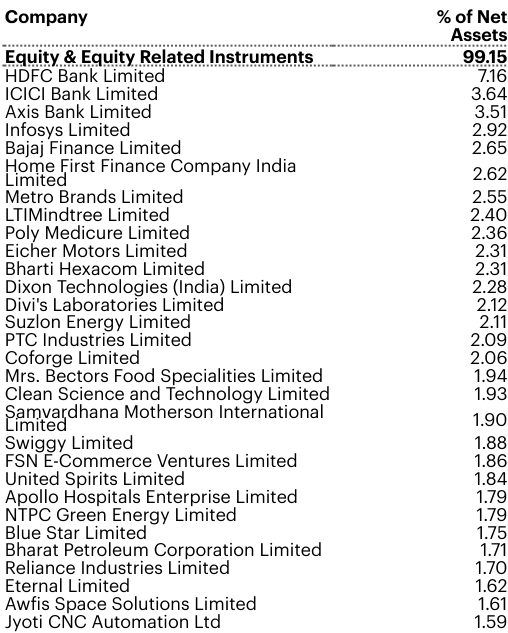

In [13]:
i = 14
box_i = results[i]['box']
IMG.crop(box_i)

In [14]:
temp = IMG.crop(box_i)

In [15]:
temp.save("table_sample.png")